# Wavelet Hash Image Matching

This notebook demonstrates the Wavelet Hash image similarity practical assignment. It compares similar and dissimilar image pairs using a Wavelet Transform, coefficient quantization, binary hashing, and Hamming distance. The notebook orchestrates the existing modules in `src/` rather than implementing their algorithms again.

## 1. Imports

The matching module delegates hash generation and distance calculation to `src/wavelet_hash.py`. The notebook only coordinates the existing pipeline.

In [9]:
from pathlib import Path

from IPython.display import Image as NotebookImage, Markdown, display

from src.evaluation import (
    calculate_roc_curve,
    evaluate_matching_results,
    plot_roc_curve,
    save_evaluation_metrics,
)
from src.matching import compare_image_pairs

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').is_dir():
    raise RuntimeError('Run this notebook from the lab4 project root.')

## 2. Configuration

Change the data directories and selected Hamming threshold here when needed. Individual image filenames are discovered from the pair directories.

In [10]:
DATA_DIR = Path('data')
SIMILAR_DIR = DATA_DIR / 'similar'
DISSIMILAR_DIR = DATA_DIR / 'dissimilar'
HAMMING_THRESHOLD = 20
SUPPORTED_IMAGE_SUFFIXES = {'.jpg', '.jpeg', '.png', '.webp'}
METRICS_PATH = Path('results/metrics/evaluation_metrics.json')
ROC_PATH = Path('results/plots/roc_curve.png')

## 3. Discover Dataset Pairs

Each valid pair directory must contain exactly `image1` and `image2` with supported image extensions. Similar pairs receive ground-truth label `1`; dissimilar pairs receive label `0`. Invalid entries are reported rather than silently ignored.

In [11]:
def discover_pairs(category_dir, ground_truth):
    if not category_dir.exists():
        print(f'Missing dataset directory: {category_dir}')
        return []
    if not category_dir.is_dir():
        print(f'Dataset path is not a directory: {category_dir}')
        return []

    entries = sorted(category_dir.iterdir())
    pair_dirs = [path for path in entries if path.is_dir()]
    non_pair_entries = [path.name for path in entries if not path.is_dir()]
    if non_pair_entries:
        print(f'Ignoring non-directory entries in {category_dir}: {non_pair_entries}')
    if not pair_dirs:
        print(f'No pair directories found in {category_dir}.')
        return []

    pairs = []
    for pair_dir in pair_dirs:
        all_files = sorted(path for path in pair_dir.iterdir() if path.is_file())
        image_paths = [
            path
            for path in all_files
            if path.suffix.lower() in SUPPORTED_IMAGE_SUFFIXES
        ]
        unsupported = [
            path.name
            for path in all_files
            if path.suffix.lower() not in SUPPORTED_IMAGE_SUFFIXES
        ]
        if unsupported:
            print(f'Unsupported files in {pair_dir}: {unsupported}')

        stems = {path.stem.lower() for path in image_paths}
        if len(image_paths) != 2 or stems != {'image1', 'image2'}:
            print(
                f'Skipping {pair_dir}: expected exactly image1 and image2 '
                'with supported formats.'
            )
            continue

        images_by_stem = {path.stem.lower(): path for path in image_paths}
        pairs.append(
            (images_by_stem['image1'], images_by_stem['image2'], ground_truth)
        )
    return pairs


PAIRS = discover_pairs(SIMILAR_DIR, 1) + discover_pairs(DISSIMILAR_DIR, 0)
if not PAIRS:
    print(
        'The dataset is empty or invalid. Add generated image pairs to '
        'data/similar/ and data/dissimilar/.'
    )
else:
    print(f'Discovered {len(PAIRS)} valid image pairs.')

Discovered 4 valid image pairs.


## 4. Run Image Matching

`compare_image_pairs()` generates each Wavelet Hash, calculates its Hamming distance, and applies the selected threshold.

In [12]:
MATCHING_RESULTS = []
if PAIRS:
    MATCHING_RESULTS = compare_image_pairs(
        PAIRS,
        threshold=HAMMING_THRESHOLD,
    )


def display_matching_table(results):
    if not results:
        print('No matching results are available.')
        return

    headers = ('Ground truth', 'Image 1', 'Image 2', 'Distance', 'Prediction')
    rows = []
    for result in results:
        prediction = 'similar' if result['predicted_label'] == 1 else 'dissimilar'
        rows.append((
            result['ground_truth'],
            Path(result['image1_path']).name,
            Path(result['image2_path']).name,
            result['hamming_distance'],
            prediction,
        ))

    widths = [
        max(len(str(headers[index])), max(len(str(row[index])) for row in rows))
        for index in range(len(headers))
    ]
    print(' | '.join(str(value).ljust(widths[index]) for index, value in enumerate(headers)))
    print('-+-'.join('-' * width for width in widths))
    for row in rows[:20]:
        print(' | '.join(str(value).ljust(widths[index]) for index, value in enumerate(row)))
    if len(rows) > 20:
        print(f'... {len(rows) - 20} additional pairs omitted.')


display_matching_table(MATCHING_RESULTS)

Ground truth | Image 1    | Image 2    | Distance | Prediction
-------------+------------+------------+----------+-----------
1            | image1.jpg | image2.jpg | 0        | similar   
1            | image1.jpg | image2.jpg | 6        | similar   
0            | image1.jpg | image2.jpg | 113      | dissimilar
0            | image1.jpg | image2.jpg | 137      | dissimilar


## 5. Evaluate the Selected Threshold

`evaluate_matching_results()` calculates the confusion counts, accuracy, sensitivity, and specificity without duplicating metric formulas in the notebook.

In [13]:
METRICS = {}
if MATCHING_RESULTS:
    METRICS = evaluate_matching_results(MATCHING_RESULTS)
    print('Metric                 Value')
    print('---------------------  -----')
    for name in ('TP', 'TN', 'FP', 'FN', 'accuracy', 'sensitivity', 'specificity'):
        print(f'{name:<21}  {METRICS[name]}')
else:
    print('Metrics skipped because no valid image pairs were discovered.')

Metric                 Value
---------------------  -----
TP                     2
TN                     2
FP                     0
FN                     0
accuracy               1.0
sensitivity            1.0
specificity            1.0


## 6. ROC Curve

`calculate_roc_curve()` evaluates multiple Hamming thresholds. At each threshold, `distance <= threshold` predicts similar; the returned TPR is sensitivity and FPR is `FP / (FP + TN)`.

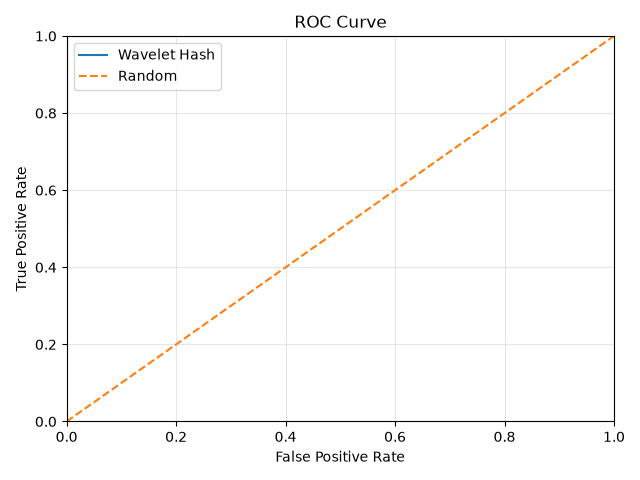

ROC points: 139
Changing the threshold changes the similarity decisions and traces the ROC curve.


In [14]:
ROC_DATA = {}
if MATCHING_RESULTS:
    ROC_DATA = calculate_roc_curve(MATCHING_RESULTS)
    ROC_PATH.parent.mkdir(parents=True, exist_ok=True)
    plot_roc_curve(ROC_DATA, ROC_PATH)
    display(NotebookImage(filename=str(ROC_PATH)))
    print(f'ROC points: {len(ROC_DATA["thresholds"])}')
    print('Changing the threshold changes the similarity decisions and traces the ROC curve.')
else:
    print('ROC skipped because no valid image pairs were discovered.')

## 7. Save Evaluation Results

The selected-threshold metrics are saved as JSON. The plotting function and this cell ensure their result directories exist automatically.

In [15]:
if MATCHING_RESULTS:
    METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
    saved_metrics_path = save_evaluation_metrics(METRICS, METRICS_PATH)
    print(f'Saved evaluation metrics to {saved_metrics_path}')
else:
    print('Metrics file skipped because no valid image pairs were discovered.')

Saved evaluation metrics to results/metrics/evaluation_metrics.json


## 8. Final Summary

The final cell reports the discovered pair counts, selected threshold, evaluation metrics, and output locations.

In [28]:
if MATCHING_RESULTS:
    similar_count = sum(result['ground_truth'] == 1 for result in MATCHING_RESULTS)
    dissimilar_count = sum(result['ground_truth'] == 0 for result in MATCHING_RESULTS)
    summary = "".join([
        '# Final Summary\n',
        f'## Similar pairs: {similar_count}\n',
        f'## Dissimilar pairs: {dissimilar_count}\n',
        f'## Selected Hamming threshold: {HAMMING_THRESHOLD}\n',
        f'## Accuracy: {METRICS["accuracy"]:.4f}\n',
        f'## Sensitivity: {METRICS["sensitivity"]:.4f}\n',
        f'## Specificity: {METRICS["specificity"]:.4f}\n',
        f'## ROC plot: {ROC_PATH}\n',
        f'## Metrics JSON: {METRICS_PATH}\n',
    ])
    display(Markdown(summary))
else:
    print('Add valid image pairs to data/ and run the notebook again for a summary.')

# Final Summary
## Similar pairs: 2
## Dissimilar pairs: 2
## Selected Hamming threshold: 20
## Accuracy: 1.0000
## Sensitivity: 1.0000
## Specificity: 1.0000
## ROC plot: results/plots/roc_curve.png
## Metrics JSON: results/metrics/evaluation_metrics.json
